# Обучение моделей  

## импорт библиотек и датасета

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42

In [15]:
df = pd.read_csv('./dataset/data_cleaning.csv')

display(df.head())
display(df.shape)

,age_groups,ag_stage,gluc,cholesterol,ap_hi,cardio
0,2,-1,1,1,110,0
1,2,1,1,3,140,1
2,2,-1,1,3,130,1
3,1,-1,1,1,150,1
4,1,-1,1,1,100,0


(69529, 6)

In [16]:
X, y = df.drop('cardio', axis=1), df['cardio']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

display(X_train)
display(X_test)

,age_groups,ag_stage,gluc,cholesterol,ap_hi
37015,2,-1,3,3,130
30057,2,-1,1,1,120
28421,2,1,1,1,140
26820,1,-1,1,1,110
49375,2,-1,1,1,140
...,...,...,...,...,...
37194,1,-1,1,1,115
6265,1,-1,1,1,120
54886,2,1,3,3,150
860,2,-1,1,1,120


,age_groups,ag_stage,gluc,cholesterol,ap_hi
68658,2,1,1,1,140
25833,2,-1,1,1,120
17346,2,1,1,3,150
27708,2,-1,1,3,110
68909,1,-1,1,1,120
...,...,...,...,...,...
65474,2,-1,2,1,120
21820,2,-1,2,2,120
53751,2,-1,1,1,140
62505,2,-1,1,1,150


## Обучение логистической регрессии

In [19]:
# LG = LogisticRegression()


# param = {
#     'penalty': ['l1', 'l2', 'elasticnet'],
#     'tol': [1e-3, 1e-4],
#     'C': np.arange(0.1, 1.5, 0.3), 
#     'fit_intercept': [True, False],
#     'class_weight': ['balanced', None],
#     'random_state': [RANDOM_STATE],
#     'solver': ['saga'],  
#     'max_iter': [10000, 20000]  
# }

# grid_search = GridSearchCV(
#     LG, 
#     param, 
#     cv=5, 
#     verbose=1,  
#     scoring=['precision', 'recall', 'roc_auc', 'accuracy'], 
#     refit='accuracy',
#     n_jobs=-1  
# )

# grid_search.fit(X_train, y_train)

In [20]:
# grid_search.best_params_
# {'C': np.float64(0.1),
#  'class_weight': None,
#  'fit_intercept': True,
#  'max_iter': 10000,
#  'penalty': 'l2',
#  'random_state': 42,
#  'solver': 'saga',
#  'tol': 0.0001}

In [21]:
# grid_search.best_score_

In [22]:
# results = grid_search.cv_results_

# print("\n--- Лучшая модель ---")
# print(f"Accuracy:  {results['mean_test_accuracy'][grid_search.best_index_]:.4f}")
# print(f"Precision: {results['mean_test_precision'][grid_search.best_index_]:.4f}")
# print(f"Recall:    {results['mean_test_recall'][grid_search.best_index_]:.4f}")
# print(f"ROC AUC:   {results['mean_test_roc_auc'][grid_search.best_index_]:.4f}")

#--- Лучшая модель ---
# Accuracy:  0.7242
# Precision: 0.7555
# Recall:    0.6614
# ROC AUC:   0.7801

In [23]:
# KNN = KNeighborsClassifier()


# param = {
#     'n_neighbors': np.arange(5, 25, 5),
#     'weights': ['uniform', 'distance'] ,
#     'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
#     'metric': ['euclidean', 'manhattan', 'minkowski'],
#     'n_jobs': [-1] 
# }

# grid_search = GridSearchCV(
#     KNN, 
#     param, 
#     cv=5, 
#     verbose=1,  
#     scoring=['precision', 'recall', 'roc_auc', 'accuracy'], 
#     refit='accuracy',
#     n_jobs=-1  
# )

# grid_search.fit(X_train, y_train)

In [24]:
# grid_search.best_params_

# {'algorithm': 'brute',
#  'metric': 'manhattan',
#  'n_jobs': -1,
#  'n_neighbors': np.int64(20),
#  'weights': 'uniform'}

In [25]:
# results = grid_search.cv_results_

# print("\n--- Лучшая модель ---")
# print(f"Accuracy:  {results['mean_test_accuracy'][grid_search.best_index_]:.4f}")
# print(f"Precision: {results['mean_test_precision'][grid_search.best_index_]:.4f}")
# print(f"Recall:    {results['mean_test_recall'][grid_search.best_index_]:.4f}")
# print(f"ROC AUC:   {results['mean_test_roc_auc'][grid_search.best_index_]:.4f}")

# --- Лучшая модель ---
# Accuracy:  0.7237
# Precision: 0.7690
# Recall:    0.6395
# ROC AUC:   0.7721

In [26]:
X_train_tree = X_train
X_test_tree = X_test

extended_param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [3, 5, 7, 10, 15, 20, 25, None],  
    'max_features': [None, 'sqrt', 'log2', 0.3, 0.5, 0.7, 0.9],
    'min_samples_split': [2, 5, 10, 15, 20],  
    'min_samples_leaf': [1, 2, 3, 5, 7, 10],  
    'random_state': [RANDOM_STATE]
}

DTC = DecisionTreeClassifier()

grid_search = GridSearchCV(
    DTC, 
    extended_param_grid, 
    cv=5, 
    verbose=1,
    scoring=['accuracy', 'precision', 'recall', 'roc_auc'],
    refit='accuracy',  
    n_jobs=-1
)

grid_search.fit(X_train_tree, y_train)

Fitting 5 folds for each of 6720 candidates, totalling 33600 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, 15, 20, 25, None],
                         'max_features': [None, 'sqrt', 'log2', 0.3, 0.5, 0.7,
                                          0.9],
                         'min_samples_leaf': [1, 2, 3, 5, 7, 10],
                         'min_samples_split': [2, 5, 10, 15, 20],
                         'random_state': [42], 'splitter': ['best', 'random']},
             refit='accuracy',
             scoring=['accuracy', 'precision', 'recall', 'roc_auc'], verbose=1)

In [27]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 0.9,
 'min_samples_leaf': 7,
 'min_samples_split': 2,
 'random_state': 42,
 'splitter': 'best'}

In [28]:
results = grid_search.cv_results_

print("\n--- Лучшая модель ---")
print(f"Accuracy:  {results['mean_test_accuracy'][grid_search.best_index_]:.4f}")
print(f"Precision: {results['mean_test_precision'][grid_search.best_index_]:.4f}")
print(f"Recall:    {results['mean_test_recall'][grid_search.best_index_]:.4f}")
print(f"ROC AUC:   {results['mean_test_roc_auc'][grid_search.best_index_]:.4f}")



--- Лучшая модель ---
Accuracy:  0.7274
Precision: 0.7550
Recall:    0.6718
ROC AUC:   0.7854


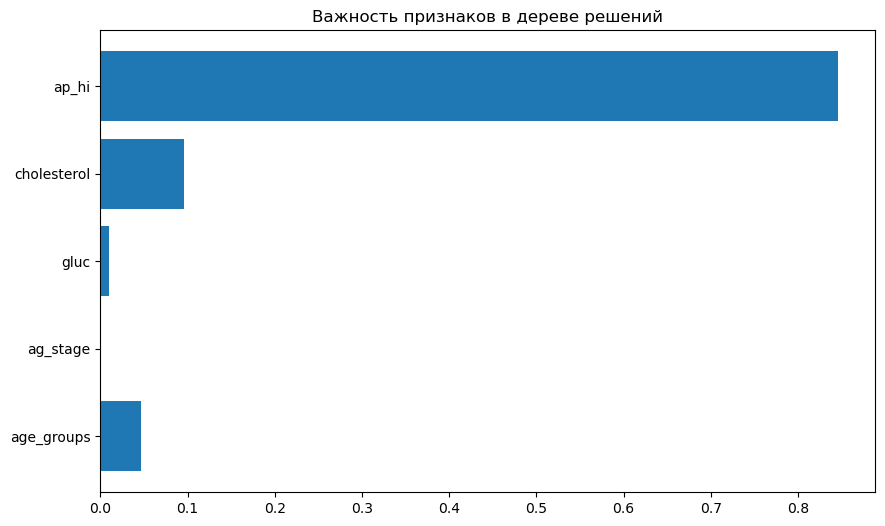

In [29]:
best_tree = grid_search.best_estimator_
importances = best_tree.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.title('Важность признаков в дереве решений')
plt.show()